<a href="https://colab.research.google.com/github/umiSirya/FUTURE_DS_01/blob/main/retail_warehouse__analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/Warehouse_and_Retail_Sales.csv')
df.head(5)

,YEAR,MONTH,SUPPLIER,ITEM CODE,ITEM DESCRIPTION,ITEM TYPE,RETAIL SALES,RETAIL TRANSFERS,WAREHOUSE SALES
0,2020,1,REPUBLIC NATIONAL DISTRIBUTING CO,100009,BOOTLEG RED - 750ML,WINE,0.00,0.0,2.0
1,2020,1,PWSWN INC,100024,MOMENT DE PLAISIR - 750ML,WINE,0.00,1.0,4.0
2,2020,1,RELIABLE CHURCHILL LLLP,1001,S SMITH ORGANIC PEAR CIDER - 18.7OZ,BEER,0.00,0.0,1.0
3,2020,1,LANTERNA DISTRIBUTORS INC,100145,SCHLINK HAUS KABINETT - 750ML,WINE,0.00,0.0,1.0
4,2020,1,DIONYSOS IMPORTS INC,100293,SANTORINI GAVALA WHITE - 750ML,WINE,0.82,0.0,0.0


# **EDA and Cleaning**

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307645 entries, 0 to 307644
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   YEAR              307645 non-null  int64  
 1   MONTH             307645 non-null  int64  
 2   SUPPLIER          307478 non-null  object 
 3   ITEM CODE         307645 non-null  object 
 4   ITEM DESCRIPTION  307645 non-null  object 
 5   ITEM TYPE         307644 non-null  object 
 6   RETAIL SALES      307642 non-null  float64
 7   RETAIL TRANSFERS  307645 non-null  float64
 8   WAREHOUSE SALES   307645 non-null  float64
dtypes: float64(3), int64(2), object(4)
memory usage: 21.1+ MB


In [4]:
# checking for null values
df.isnull().sum()

,0
YEAR,0
MONTH,0
SUPPLIER,167
ITEM CODE,0
ITEM DESCRIPTION,0
ITEM TYPE,1
RETAIL SALES,3
RETAIL TRANSFERS,0
WAREHOUSE SALES,0


In [5]:
#checking for duplicates
df.duplicated().sum()

np.int64(0)

In [6]:
#statistics summary of the dataset
df.describe()

,YEAR,MONTH,RETAIL SALES,RETAIL TRANSFERS,WAREHOUSE SALES
count,307645.000000,307645.000000,307642.000000,307645.000000,307645.000000
mean,2018.438525,6.423862,7.024071,6.936465,25.294597
std,1.083061,3.461812,30.986238,30.237195,249.916798
min,2017.000000,1.000000,-6.490000,-38.490000,-7800.000000
25%,2017.000000,3.000000,0.000000,0.000000,0.000000
50%,2019.000000,7.000000,0.320000,0.000000,1.000000
75%,2019.000000,9.000000,3.267500,3.000000,5.000000
max,2020.000000,12.000000,2739.000000,1990.830000,18317.000000


In [8]:
# Fix nulls
df['RETAIL SALES'] = df['RETAIL SALES'].fillna(0)
df['SUPPLIER'] = df['SUPPLIER'].fillna('UNKNOWN')
df['ITEM TYPE'] = df['ITEM TYPE'].fillna('UNKNOWN')

# Drop rows where all 3 sales columns are zero (no business value)
df = df[~((df['RETAIL SALES'] == 0) & (df['RETAIL TRANSFERS'] == 0) & (df['WAREHOUSE SALES'] == 0))]

In [9]:

# Add a proper DATE column
df['DATE'] = pd.to_datetime(df['YEAR'].astype(str) + '-' + df['MONTH'].astype(str).str.zfill(2) + '-01')

In [11]:
# Add a TOTAL SALES column
df['TOTAL SALES'] = df['RETAIL SALES'] + df['RETAIL TRANSFERS'] + df['WAREHOUSE SALES']

# Verify no nulls remain
print(df.isnull().sum())
print(df.shape)

YEAR                0
MONTH               0
SUPPLIER            0
ITEM CODE           0
ITEM DESCRIPTION    0
ITEM TYPE           0
RETAIL SALES        0
RETAIL TRANSFERS    0
WAREHOUSE SALES     0
DATE                0
TOTAL SALES         0
dtype: int64
(306513, 11)


In [22]:
# staving data from 2019 moving forward because of the data gap between 2018 and 2019
df = df[df['YEAR'] >= 2019]

# Save
df.to_csv('Warehouse_Retail_Sales_Cleaned.csv', index=False)


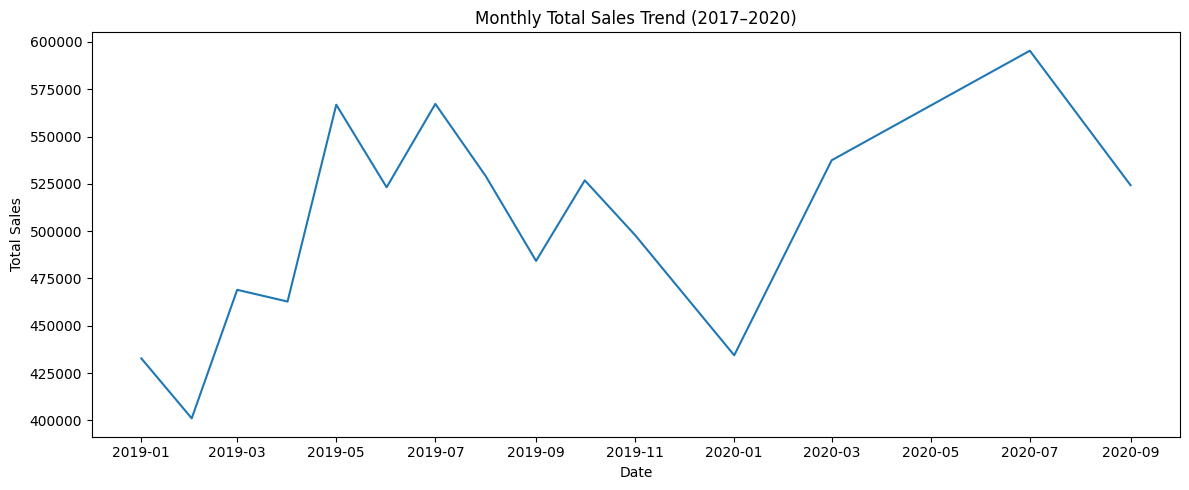

In [23]:
#  Total sales trend over time (monthly)
df = df.copy()

monthly = df.groupby('DATE')['TOTAL SALES'].sum().reset_index()
plt.figure(figsize=(12, 5))
plt.plot(monthly['DATE'], monthly['TOTAL SALES'])
plt.title('Monthly Total Sales Trend (2017–2020)')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.savefig('chart1_sales_trend.png')
plt.show()

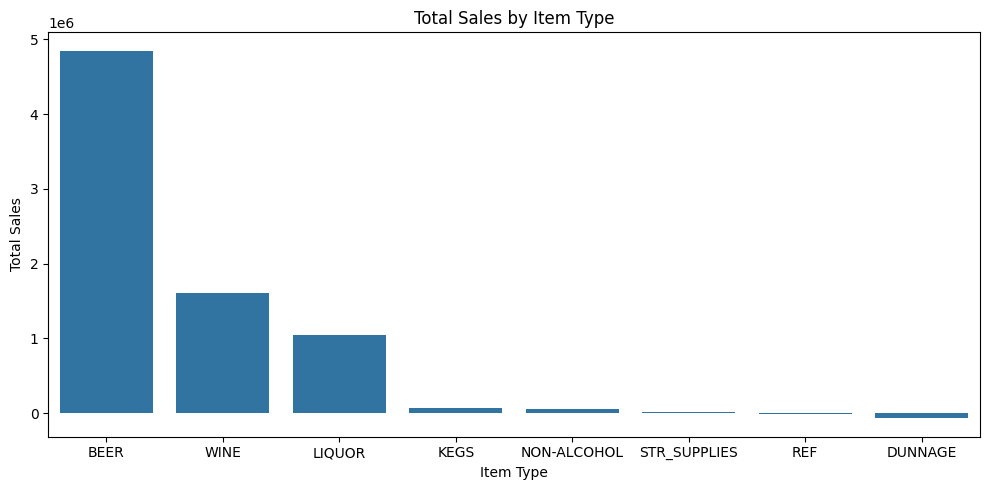

In [24]:
#  Sales by Item Type (bar chart)
by_type = df.groupby('ITEM TYPE')['TOTAL SALES'].sum().sort_values(ascending=False).reset_index()
plt.figure(figsize=(10, 5))
sns.barplot(data=by_type, x='ITEM TYPE', y='TOTAL SALES')
plt.title('Total Sales by Item Type')
plt.xlabel('Item Type')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.savefig('chart2_sales_by_type.png')
plt.show()

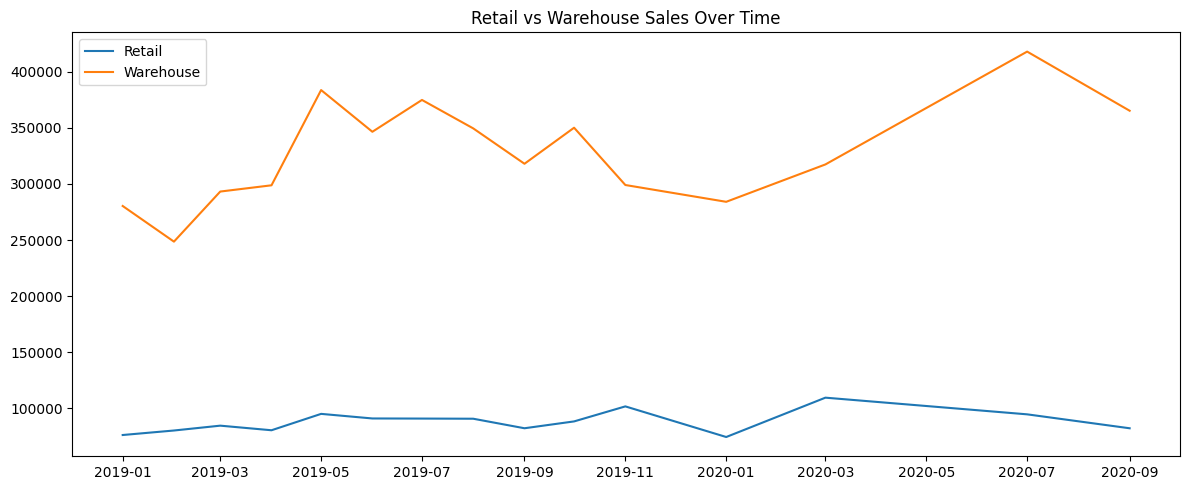

In [25]:
# Retail vs Warehouse sales over time

channel = df.groupby('DATE')[['RETAIL SALES', 'WAREHOUSE SALES']].sum().reset_index()
plt.figure(figsize=(12, 5))
plt.plot(channel['DATE'], channel['RETAIL SALES'], label='Retail')
plt.plot(channel['DATE'], channel['WAREHOUSE SALES'], label='Warehouse')
plt.title('Retail vs Warehouse Sales Over Time')
plt.legend()
plt.tight_layout()
plt.savefig('chart3_retail_vs_warehouse.png')
plt.show()

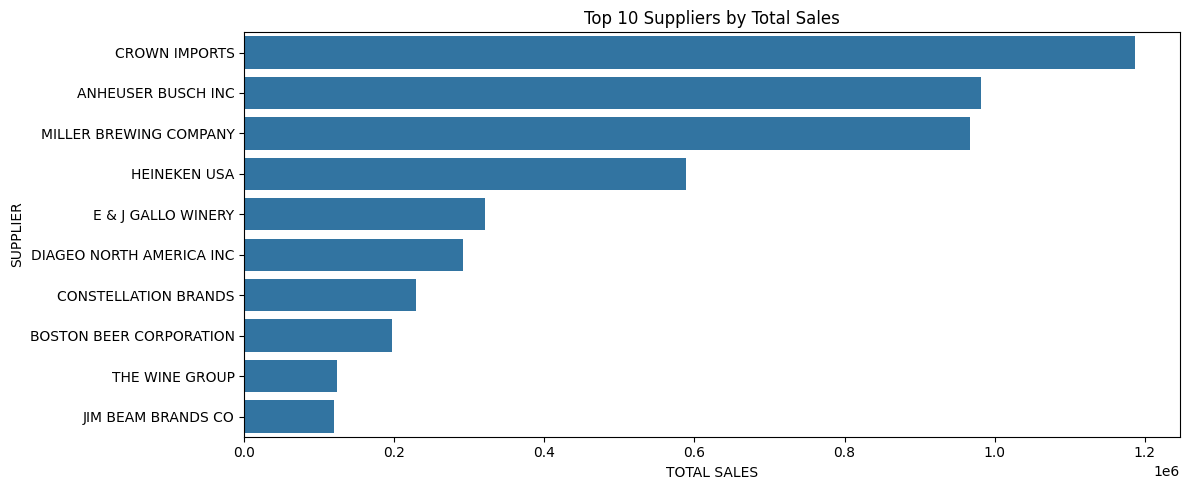

In [26]:
# Top 10 suppliers by total sales
top_suppliers = df.groupby('SUPPLIER')['TOTAL SALES'].sum().sort_values(ascending=False).head(10).reset_index()
plt.figure(figsize=(12, 5))
sns.barplot(data=top_suppliers, x='TOTAL SALES', y='SUPPLIER')
plt.title('Top 10 Suppliers by Total Sales')
plt.tight_layout()
plt.savefig('chart4_top_suppliers.png')
plt.show()
